# Exploración de los nueve archivos de origen (previa a la capa Bronze)

**Objetivo.** Ver el contenido real de cada archivo para poder definir el esquema exacto de las tablas Bronze.
Este notebook **no transforma ni carga nada**: solo lee y perfila.

**Estructura**

| Sección | Qué responde |
|---|---|
| 1. Inventario | tamaño, líneas, encoding, BOM, delimitador, hash y líneas malformadas por archivo (base de la conciliación origen = Bronze + malformadas) |
| 2. Funciones de perfilado | los pasos del lab de referencia (shape, dtypes, nulos, % nulos, info) más duplicados y valores centinela |
| 3. Catálogos | 4 archivos de estaciones/paradas |
| 4. Operativos CSV | Transmetro, Transurbano, Aerómetro |
| 5. MetroRiel (JSON Lines) | rutas del JSON, anidamiento, deriva de esquema, si trae hora |
| 6. CDC del padrón | columna de operación, secuencia, orden, patrones por tarjeta |
| 7. Llaves de usuario | formatos y llaves distintas por operador |
| 8. Resumen | tabla de hallazgos y decisiones que este notebook debe confirmar |

**Cómo usarlo:** colocar el notebook junto a la carpeta `datos_red/` (o ajustar `DATA_DIR`) y ejecutar de arriba hacia abajo.
Las celdas marcadas con **AJUSTAR** piden que fijes un nombre de columna después de ver los encabezados.

## 0. Instalación y configuración

In [5]:
import csv, hashlib, json, re
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 80)

DATA_DIR = Path("datos_red_completo")

ARCHIVOS = {
    # catálogos (batch)
    "tm_estaciones":  "tm_estaciones.csv",
    "tu_paradas":     "tu_paradas.csv",
    "mr_estaciones":  "mr_estaciones.csv",
    "am_estaciones":  "am_estaciones.csv",
    # operativos
    "transmetro_validaciones":    "transmetro_validaciones.csv",     # streaming
    "aerometro_boardings":        "aerometro_boardings.csv",         # streaming
    "transurbano_transacciones":  "transurbano_transacciones.csv",   # batch
    "metroriel_viajes":           "metroriel_viajes.jsonl",          # batch
    # CDC
    "cdc_padron_usuarios":        "cdc_padron_usuarios.csv",         # CDC
}

# Para archivos muy grandes se puede perfilar solo una muestra de filas (None = todo)
MAX_FILAS = None
# Para el análisis de rutas del JSON de MetroRiel
MUESTRA_JSON = 200_000

faltantes = [n for n, f in ARCHIVOS.items() if not (DATA_DIR / f).exists()]
print("Archivos faltantes:", faltantes if faltantes else "ninguno")

Archivos faltantes: ninguno


## 1. Inventario de archivos

Una sola pasada por archivo. De aquí salen: **conteo de origen** (la mitad izquierda de la conciliación),
**hash** (llave de idempotencia en batch), **BOM/encoding** (afecta al leer el encabezado) y **líneas malformadas**.

In [6]:
def inspeccionar_archivo(path):
    """Una pasada binaria: tamaño, líneas, BOM, líneas no UTF-8, sha256, primera línea."""
    h = hashlib.sha256()
    lineas = no_utf8 = 0
    primera = None
    with open(path, "rb") as f:
        bom = f.read(3) == b"\xef\xbb\xbf"
        f.seek(0)
        for linea in f:
            h.update(linea)
            lineas += 1
            if primera is None:
                primera = linea
            try:
                linea.decode("utf-8")
            except UnicodeDecodeError:
                no_utf8 += 1
    enc = primera.decode("utf-8", errors="replace").lstrip("\ufeff").rstrip("\r\n") if primera else ""
    return {
        "size_mb": round(path.stat().st_size / 1e6, 2),
        "lineas_totales": lineas,
        "bom_utf8": bom,
        "lineas_no_utf8": no_utf8,
        "sha256": h.hexdigest(),
        "primera_linea": enc,
    }

def detectar_delimitador(primera_linea):
    cuentas = {d: primera_linea.count(d) for d in [",", ";", "\t", "|"]}
    return max(cuentas, key=cuentas.get) if any(cuentas.values()) else None

def validar_campos_csv(path, sep=","):
    """Cuenta filas con distinto número de campos que el encabezado (candidatas a 'malformadas')."""
    malas = []
    with open(path, newline="", encoding="utf-8-sig", errors="replace") as f:
        reader = csv.reader(f, delimiter=sep)
        header = next(reader)
        n = len(header)
        filas = 0
        for fila in reader:
            filas += 1
            if len(fila) != n:
                malas.append((reader.line_num, len(fila)))
    return header, filas, malas

In [16]:
inventario = []
malformadas_csv = {}

for nombre, archivo in ARCHIVOS.items():
    p = DATA_DIR / archivo
    if not p.exists():
        continue
    info = inspeccionar_archivo(p)
    info["archivo"] = archivo
    info["tipo"] = "jsonl" if archivo.endswith(".jsonl") else "csv"
    if info["tipo"] == "csv":
        sep = detectar_delimitador(info["primera_linea"]) or ","
        header, filas, malas = validar_campos_csv(p, sep)
        info.update({"delimitador": repr(sep), "n_columnas_encabezado": len(header),
                     "filas_datos": filas, "filas_campos_distintos": len(malas)})
        malformadas_csv[nombre] = malas
    else:
        info.update({"delimitador": "-", "n_columnas_encabezado": None,
                     "filas_datos": info["lineas_totales"], "filas_campos_distintos": None})
    inventario.append(info)

inv = pd.DataFrame(inventario).set_index("archivo")
inv[["tipo", "size_mb", "lineas_totales", "filas_datos", "delimitador",
     "n_columnas_encabezado", "filas_campos_distintos", "bom_utf8", "lineas_no_utf8"]]

,tipo,size_mb,lineas_totales,filas_datos,delimitador,n_columnas_encabezado,filas_campos_distintos,bom_utf8,lineas_no_utf8
archivo,,,,,,,,,
tm_estaciones.csv,csv,0.01,105,104,"','",6.0,0.0,False,0
tu_paradas.csv,csv,0.01,329,328,"','",4.0,0.0,False,0
mr_estaciones.csv,csv,0.00,23,22,"','",4.0,0.0,False,0
am_estaciones.csv,csv,0.00,15,14,"','",4.0,0.0,False,0
transmetro_validaciones.csv,csv,24.04,363222,363221,"','",7.0,0.0,False,0
aerometro_boardings.csv,csv,12.12,203555,203554,"','",7.0,0.0,False,0
transurbano_transacciones.csv,csv,43.13,832792,832791,"','",7.0,0.0,False,0
metroriel_viajes.jsonl,jsonl,55.31,299100,299100,-,NaN,NaN,False,0
cdc_padron_usuarios.csv,csv,2.15,31051,31050,"','",7.0,0.0,False,0


In [8]:
# Encabezados tal como llegan (para decidir la normalización a minúsculas y ver espacios/acentos)
for archivo, fila in inv.iterrows():
    if fila["tipo"] == "csv":
        cols = fila["primera_linea"].split(eval(fila["delimitador"]))
        raros = [c for c in cols if c != c.strip() or re.search(r"[^\w]", c) or not c.isascii()]
        print(f"{archivo}\n  {cols}\n  columnas con espacios/acentos/símbolos: {raros or 'ninguna'}\n")

tm_estaciones.csv
  ['estacion_id', 'nombre', 'linea', 'zona', 'lat', 'lon']
  columnas con espacios/acentos/símbolos: ninguna

tu_paradas.csv
  ['cod_parada', 'descripcion', 'ruta', 'sector']
  columnas con espacios/acentos/símbolos: ninguna

mr_estaciones.csv
  ['id_estacion', 'nombre_estacion', 'zona_nombre', 'km']
  columnas con espacios/acentos/símbolos: ninguna

am_estaciones.csv
  ['station_code', 'station_name', 'axis', 'district']
  columnas con espacios/acentos/símbolos: ninguna

transmetro_validaciones.csv
  ['validacion_id', 'tarjeta', 'estacion_id', 'linea', 'fecha_hora', 'tarifa', 'tipo']
  columnas con espacios/acentos/símbolos: ninguna

aerometro_boardings.csv
  ['boarding_id', 'user_hash', 'station_code', 'axis', 'timestamp_utc', 'cabin_number', 'fare']
  columnas con espacios/acentos/símbolos: ninguna

transurbano_transacciones.csv
  ['fecha', 'hora', 'num_tarjeta', 'cod_parada', 'ruta', 'monto_centavos', 'cod_estado']
  columnas con espacios/acentos/símbolos: ninguna

In [9]:
# Hash por archivo (llave de idempotencia en batch) y ejemplos de filas con campos distintos
print(inv["sha256"].to_string())
for nombre, malas in malformadas_csv.items():
    if malas:
        print(f"\n{nombre}: {len(malas)} filas con distinto nº de campos. Primeras:", malas[:5])

archivo
tm_estaciones.csv                4d53a95abb4f115b7da7f69db2c392e1748d6704807d81408a5e510f791624d0
tu_paradas.csv                   a888a09c45189cfeac0a0577377d1b4c662923ee55f798d961f418aa2ac93b90
mr_estaciones.csv                c302ffbc6f0bdcf926c8eaaf9a5427ec5d38d482cc44431e3aeb20a8febb8e8c
am_estaciones.csv                e3acbeed8608fb9a6b9a8df87646bf5294e644aa64bd95484f1424b92ae21723
transmetro_validaciones.csv      5f88356e427d0ec19b193f6aaafedc288d9bf3fbad1881f011a7d9ea912730d2
aerometro_boardings.csv          898b871c6b3457b6b63a522d5dd8966e3a75bcaf215156a65c4a9d211af4cdc7
transurbano_transacciones.csv    8ce5028499b7b6c7274fd838430e87d373065d377e5ec1f062a4fa6497083fad
metroriel_viajes.jsonl           23feb4a3a55ce506bf34de5faf7834f9c390b7ca70499cc9fb3ec1c3650ebede
cdc_padron_usuarios.csv          68e4d9dd258809dd4a45a0c5f9023ad6f3b5d32912e4447b9d20b9a7258de5c4


## 2. Funciones de perfilado

Se leen **todas las columnas como texto** (`dtype=str`), igual que la política de Bronze. Solo la cadena vacía cuenta como nulo;
así los valores como `NULL`, `N/A` o `-` no quedan escondidos (se cuentan aparte como *centinelas*).

`perfilar` reproduce los pasos del lab de referencia (shape, dtypes, nulos, % nulos, info) y añade:
- **dtypes que pandas inferiría**: muestra qué se rompería si no se guardara como STRING (por ejemplo, llaves con ceros a la izquierda).
- filas duplicadas exactas y valores centinela.

In [48]:
CENTINELAS = {"NULL", "null", "None", "N/A", "NA", "nan", "NaN", "-", "--", "?"}

def leer_csv(nombre, **kw):
    p = DATA_DIR / ARCHIVOS[nombre]
    return pd.read_csv(p, dtype=str, keep_default_na=False, na_values=[""],
                       nrows=MAX_FILAS, encoding="utf-8-sig", on_bad_lines="warn", **kw)

def perfilar(df, nombre, nrows_inferencia=50_000):
    print(f"===== {nombre} =====")
    print("Shape:", df.shape)

    inferidos = pd.read_csv(DATA_DIR / ARCHIVOS[nombre], nrows=nrows_inferencia,
                            encoding="utf-8-sig", on_bad_lines="skip").dtypes
    print("\nDtypes (leído como texto) vs. dtype que pandas inferiría:")
    print(pd.DataFrame({"leido": df.dtypes, "inferido": inferidos}))

    print("\nNulos por columna:")
    print(df.isna().sum())

    pct_nulos = (df.isna().sum() / len(df) * 100).round(2)
    print("\n% de nulos por columna:")
    print(pct_nulos.sort_values(ascending=False))

    print("\nInfo general:")
    df.info()

    print("\nFilas duplicadas exactas:", df.duplicated().sum())

    cent = df.apply(lambda s: s.isin(CENTINELAS).sum())
    cent = cent[cent > 0]
    print("Valores centinela (NULL, N/A, -, ...):", cent.to_dict() if len(cent) else "ninguno")

def matriz_nulos(df, nombre, n=5000):
    """Matriz de nulos (missingno) sobre una muestra."""
    msno.matrix(df.sample(min(len(df), n), random_state=1), figsize=(10, 3), sparkline=False)
    plt.title(f"Nulos: {nombre} (muestra)")
    plt.show()

def patron_formato(serie, top=10):
    """Convierte cada valor a su 'forma' (dígito→9, letra→A) para ver mezclas de formato."""
    forma = (serie.dropna().astype(str)
             .str.replace(r"\d", "9", regex=True)
             .str.replace(r"[A-Za-z]", "A", regex=True))
    return forma.value_counts().head(top)

PATRONES = {
    "fecha/hora":    r"fecha|hora|time|date|^ts|_ts$|_at$",
    "llave usuario": r"user|usuario|tarjeta|card|llave|key|cliente|hash",
    "dinero":        r"monto|total|tarifa|precio|costo|amount|fare|valor|pago|saldo|cobro",
    "zona":          r"zona|district|zone",
}

def candidatas(df, tipo):
    return [c for c in df.columns if re.search(PATRONES[tipo], c, flags=re.I)]

def parsear_fecha(serie):
    try:
        return pd.to_datetime(serie, errors="coerce", format="mixed")
    except Exception:
        return pd.to_datetime(serie, errors="coerce")

def explorar_semantica(df, nombre):
    """Formato de fechas, llaves, dinero y zonas de un archivo operativo (columnas candidatas por nombre)."""
    print(f"\n########## Semántica: {nombre} ##########")

    for c in candidatas(df, "fecha/hora"):
        s = df[c]
        p = parsear_fecha(s)
        no_parse = (p.isna() & s.notna()).sum()
        print(f"\n[fecha/hora] {c}  |  ejemplos: {s.dropna().head(3).tolist()}")
        print(f"  no parseables: {no_parse}  |  min: {p.min()}  |  max: {p.max()}")
        print(f"  ¿trae componente hora?: {(p.dt.hour.fillna(0) != 0).any() if p.notna().any() else 'n/d'}")
        print("  formas:", patron_formato(s, 5).to_dict())

    for c in candidatas(df, "llave usuario"):
        s = df[c]
        print(f"\n[llave] {c}  |  ejemplos: {s.dropna().head(3).tolist()}  |  distintas: {s.nunique()}")
        print("  formas:", patron_formato(s, 5).to_dict())
        print("  longitudes:", s.dropna().str.len().value_counts().head(5).to_dict())

    for c in candidatas(df, "dinero"):
        n = pd.to_numeric(df[c], errors="coerce")
        ejemplos = df[c].dropna().head(3).tolist()
        no_numericos = (n.isna() & df[c].notna()).sum()
        tiene_decimales = df[c].dropna().str.contains(r"\.").any()

        print(f"\n[dinero] {c}  |  ejemplos: {ejemplos}")
        print(f"  no numéricos: {no_numericos}  |  min {n.min()}  mediana {n.median()}  max {n.max()}  |  con decimales: {tiene_decimales}")


    for c in candidatas(df, "zona"):
        print(f"\n[zona] {c}  |  distintos: {df[c].nunique()}")
        print(df[c].value_counts(dropna=False).head(12).to_string())

## 3. Catálogos (batch)

Los cuatro son *snapshots* pequeños. Interesa: nombre de columnas, llave del catálogo (¿es única?) y cómo se escribe la zona en cada uno.

In [11]:
catalogos = {}
for nombre in ["tm_estaciones", "tu_paradas", "mr_estaciones", "am_estaciones"]:
    catalogos[nombre] = leer_csv(nombre)
    display(catalogos[nombre].head(8))
    perfilar(catalogos[nombre], nombre)
    print()

,estacion_id,nombre,linea,zona,lat,lon
0,TM-L1-01,Estación Centra Sur - Centro 1,L1,Zona 4,14.481442,-90.549547
1,TM-L1-02,Estación Centra Sur - Centro 2,L1,Zona 6,14.552128,-90.4852
2,TM-L1-03,Estación Centra Sur - Centro 3,L1,Zona 7,14.478475,-90.599809
3,TM-L1-04,Estación Centra Sur - Centro 4,L1,Zona 8,14.568186,-90.539819
4,TM-L1-05,Estación Centra Sur - Centro 5,L1,Zona 9,14.601007,-90.541394
5,TM-L1-06,Estación Centra Sur - Centro 6,L1,Zona 10,14.591497,-90.501739
6,TM-L1-07,Estación Centra Sur - Centro 7,L1,Zona 11,14.595185,-90.534426
7,TM-L1-08,Estación Centra Sur - Centro 8,L1,Zona 12,14.503188,-90.529443


===== tm_estaciones =====
Shape: (104, 6)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
            leido inferido
estacion_id   str      str
nombre        str      str
linea         str      str
zona          str      str
lat           str  float64
lon           str  float64

Nulos por columna:
estacion_id    0
nombre         0
linea          0
zona           0
lat            0
lon            0
dtype: int64

% de nulos por columna:
estacion_id    0.0
nombre         0.0
linea          0.0
zona           0.0
lat            0.0
lon            0.0
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   estacion_id  104 non-null    str  
 1   nombre       104 non-null    str  
 2   linea        104 non-null    str  
 3   zona         104 non-null    str  
 4   lat          104 non-null    str  
 5   lon          104 non-null   

,cod_parada,descripcion,ruta,sector
0,R-101-1,Parada 1 ruta R-101,R-101,Z4
1,R-101-2,Parada 2 ruta R-101,R-101,Z6
2,R-101-3,Parada 3 ruta R-101,R-101,Z7
3,R-101-4,Parada 4 ruta R-101,R-101,Z8
4,R-101-5,Parada 5 ruta R-101,R-101,Z9
5,R-101-6,Parada 6 ruta R-101,R-101,Z10
6,R-101-7,Parada 7 ruta R-101,R-101,Z11
7,R-101-8,Parada 8 ruta R-101,R-101,Z12


===== tu_paradas =====
Shape: (328, 4)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
            leido inferido
cod_parada    str      str
descripcion   str      str
ruta          str      str
sector        str      str

Nulos por columna:
cod_parada     0
descripcion    0
ruta           0
sector         0
dtype: int64

% de nulos por columna:
cod_parada     0.0
descripcion    0.0
ruta           0.0
sector         0.0
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   cod_parada   328 non-null    str  
 1   descripcion  328 non-null    str  
 2   ruta         328 non-null    str  
 3   sector       328 non-null    str  
dtypes: str(4)
memory usage: 10.4 KB

Filas duplicadas exactas: 0
Valores centinela (NULL, N/A, -, ...): ninguno



,id_estacion,nombre_estacion,zona_nombre,km
0,1,MR 01,Zona 12,0.95
1,2,MR 02,Zona 12,1.91
2,3,MR 03,Zona 12,2.86
3,4,MR 04,Zona 12,3.82
4,5,MR 05,Zona 8,4.77
5,6,MR 06,Zona 8,5.73
6,7,MR 07,Zona 8,6.68
7,8,MR 08,Zona 8,7.64


===== mr_estaciones =====
Shape: (22, 4)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
                leido inferido
id_estacion       str    int64
nombre_estacion   str      str
zona_nombre       str      str
km                str  float64

Nulos por columna:
id_estacion        0
nombre_estacion    0
zona_nombre        0
km                 0
dtype: int64

% de nulos por columna:
id_estacion        0.0
nombre_estacion    0.0
zona_nombre        0.0
km                 0.0
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id_estacion      22 non-null     str  
 1   nombre_estacion  22 non-null     str  
 2   zona_nombre      22 non-null     str  
 3   km               22 non-null     str  
dtypes: str(4)
memory usage: 832.0 bytes

Filas duplicadas exactas: 0
Valores centinela (NULL, N/A, -, ...): ninguno



,station_code,station_name,axis,district
0,AM11,Aerometro Eje 1 - Torre 1,Eje 1,Mixco
1,AM12,Aerometro Eje 1 - Torre 2,Eje 1,Mixco
2,AM13,Aerometro Eje 1 - Torre 3,Eje 1,Mixco
3,AM14,Aerometro Eje 1 - Torre 4,Eje 1,Zona 12
4,AM15,Aerometro Eje 1 - Torre 5,Eje 1,Zona 13
5,AM16,Aerometro Eje 1 - Torre 6,Eje 1,Zona 17
6,AM17,Aerometro Eje 1 - Torre 7,Eje 1,Zona 18
7,AM21,Aerometro Eje 2 - Torre 1,Eje 2,Zona 7


===== am_estaciones =====
Shape: (14, 4)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
             leido inferido
station_code   str      str
station_name   str      str
axis           str      str
district       str      str

Nulos por columna:
station_code    0
station_name    0
axis            0
district        0
dtype: int64

% de nulos por columna:
station_code    0.0
station_name    0.0
axis            0.0
district        0.0
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   station_code  14 non-null     str  
 1   station_name  14 non-null     str  
 2   axis          14 non-null     str  
 3   district      14 non-null     str  
dtypes: str(4)
memory usage: 576.0 bytes

Filas duplicadas exactas: 0
Valores centinela (NULL, N/A, -, ...): ninguno



In [12]:
# ¿Qué columna identifica de forma única cada fila del catálogo? Y ¿cómo se escribe la zona?
for nombre, df in catalogos.items():
    unicas = [c for c in df.columns if df[c].is_unique]
    print(f"{nombre}: filas={len(df)}  columnas únicas (posible llave)={unicas}")
    for c in candidatas(df, "zona"):
        print(f"   {c}: {df[c].dropna().unique()[:8].tolist()}")

tm_estaciones: filas=104  columnas únicas (posible llave)=['estacion_id', 'nombre', 'lat', 'lon']
   zona: ['Zona 4', 'Zona 6', 'Zona 7', 'Zona 8', 'Zona 9', 'Zona 10', 'Zona 11', 'Zona 12']
tu_paradas: filas=328  columnas únicas (posible llave)=['cod_parada', 'descripcion']
mr_estaciones: filas=22  columnas únicas (posible llave)=['id_estacion', 'nombre_estacion', 'km']
   zona_nombre: ['Zona 12', 'Zona 8', 'Zona 1', 'Zona 6', 'Zona 17']
am_estaciones: filas=14  columnas únicas (posible llave)=['station_code', 'station_name']
   district: ['Mixco', 'Zona 12', 'Zona 13', 'Zona 17', 'Zona 18', 'Zona 7', 'Villa Nueva', 'San Miguel Petapa']


## 4. Operativos en CSV

Transmetro y Aerómetro entran por **streaming**, Transurbano por **batch**.
Para cada uno: muestra, perfil, matriz de nulos y semántica (fechas, llaves, dinero, zonas).

### 4.1 `transmetro_validaciones.csv` (una fila = un abordaje)

,validacion_id,tarjeta,estacion_id,linea,fecha_hora,tarifa,tipo
0,1,TC-00013132,TM-L6-01,L6,2026-06-01 04:50:57,1.00,TRANSBORDO
1,2,TC-00002679,TM-L7-08,L7,2026-06-01 17:41:09,1.00,ENTRADA
2,3,TC-00007908,TM-L7-09,L7,2026-06-01 16:02:07,1.00,ENTRADA
3,4,TC-00017298,TM-L13-10,L13,2026-06-01 17:48:14,1.00,ENTRADA
4,5,TC-00015220,TM-R5-02,R5,2026-06-01 17:02:17,1.00,ENTRADA
5,6,TC-00017100,TM-L7-07,L7,2026-06-01 18:34:37,0.50,ENTRADA
6,7,TC-00043833,TM-L2-13,L2,2026-06-01 06:56:14,1.00,ENTRADA
7,8,TC-00007461,TM-L7-13,L7,2026-06-01 04:51:42,0.50,ENTRADA


===== transmetro_validaciones =====
Shape: (363221, 7)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
              leido inferido
validacion_id   str    int64
tarjeta         str      str
estacion_id     str      str
linea           str      str
fecha_hora      str      str
tarifa          str  float64
tipo            str      str

Nulos por columna:
validacion_id    0
tarjeta          0
estacion_id      0
linea            0
fecha_hora       0
tarifa           0
tipo             0
dtype: int64

% de nulos por columna:
validacion_id    0.0
tarjeta          0.0
estacion_id      0.0
linea            0.0
fecha_hora       0.0
tarifa           0.0
tipo             0.0
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 363221 entries, 0 to 363220
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   validacion_id  363221 non-null  str  
 1   tarjeta        363221 non-null  str  
 2   estacion_i

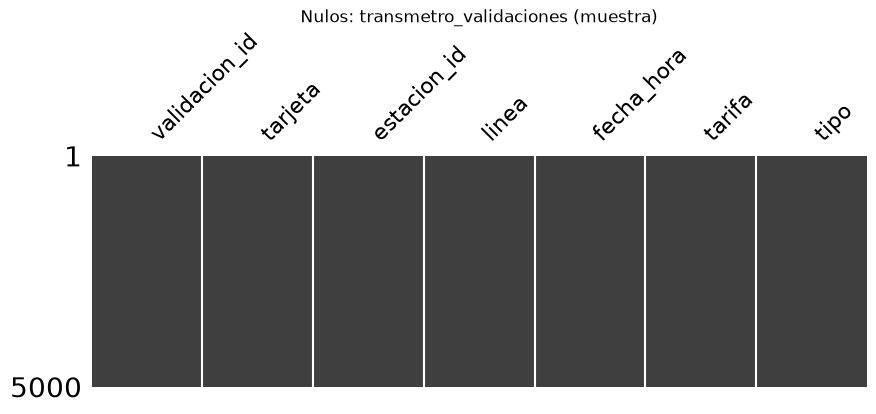


########## Semántica: transmetro_validaciones ##########

[fecha/hora] fecha_hora  |  ejemplos: ['2026-06-01 04:50:57', '2026-06-01 17:41:09', '2026-06-01 16:02:07']
  no parseables: 0  |  min: 2026-06-01 04:00:06  |  max: 2026-07-15 22:59:50
  ¿trae componente hora?: True
  formas: {'9999-99-99 99:99:99': 363221}

[llave] tarjeta  |  ejemplos: ['TC-00013132', 'TC-00002679', 'TC-00007908']  |  distintas: 43255
  formas: {'AA-99999999': 363221}
  longitudes: {11: 363221}

[dinero] tarifa  |  ejemplos: ['1.00', '1.00', '1.00']
  no numéricos: 0  |  min 0.0  mediana 1.0  max 1.0  |  con decimales: True


In [13]:
tm = leer_csv("transmetro_validaciones")
display(tm.head(8))
perfilar(tm, "transmetro_validaciones")
matriz_nulos(tm, "transmetro_validaciones")
explorar_semantica(tm, "transmetro_validaciones")

### 4.2 `transurbano_transacciones.csv` (una fila = una transacción; fecha y hora en columnas separadas)

,fecha,hora,num_tarjeta,cod_parada,ruta,monto_centavos,cod_estado
0,01/06/2026,06:15:16,0000025494,R-118-6,R-118,130,3
1,01/06/2026,22:14:48,0000058521,R-107-5,R-107,65,2
2,01/06/2026,18:23:23,0000003930,R-135-1,R-135,65,2
3,01/06/2026,06:09:39,0000017117,R-109-5,R-109,130,1
4,01/06/2026,06:02:40,0000022400,R-102-8,R-102,130,3
5,01/06/2026,11:18:56,0000004437,R-135-2,R-135,130,2
6,01/06/2026,07:52:43,0000046805,R-120-7,R-120,130,2
7,01/06/2026,07:00:17,0000044766,R-135-4,R-135,130,2


===== transurbano_transacciones =====
Shape: (832791, 7)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
               leido inferido
fecha            str      str
hora             str      str
num_tarjeta      str    int64
cod_parada       str      str
ruta             str      str
monto_centavos   str    int64
cod_estado       str    int64

Nulos por columna:
fecha                0
hora                 0
num_tarjeta          0
cod_parada        4189
ruta                 0
monto_centavos       0
cod_estado           0
dtype: int64

% de nulos por columna:
cod_parada        0.5
hora              0.0
fecha             0.0
num_tarjeta       0.0
ruta              0.0
monto_centavos    0.0
cod_estado        0.0
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 832791 entries, 0 to 832790
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   fecha           832791 non-null  str  
 1   hora 

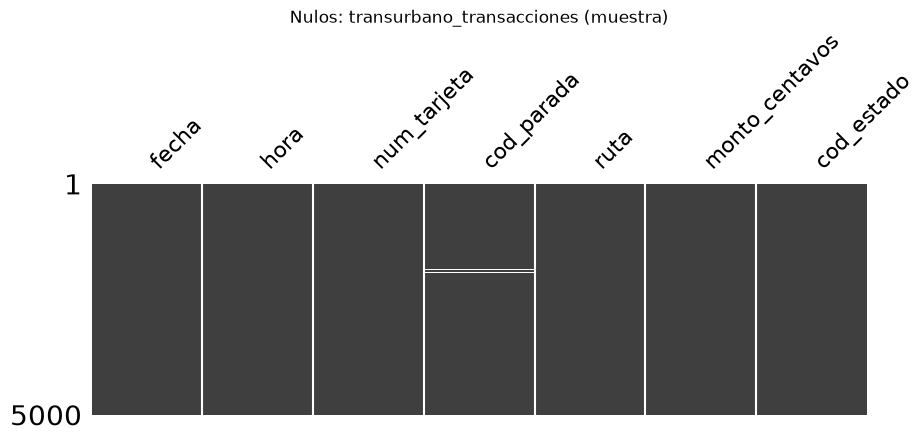


########## Semántica: transurbano_transacciones ##########

[fecha/hora] fecha  |  ejemplos: ['01/06/2026', '01/06/2026', '01/06/2026']
  no parseables: 0  |  min: 2026-01-06 00:00:00  |  max: 2027-12-08 00:00:00
  ¿trae componente hora?: False
  formas: {'99/99/9999': 832791}

[fecha/hora] hora  |  ejemplos: ['06:15:16', '22:14:48', '18:23:23']
  no parseables: 0  |  min: 2026-09-20 04:00:00  |  max: 2026-09-20 22:59:59
  ¿trae componente hora?: True
  formas: {'99:99:99': 832791}

[llave] num_tarjeta  |  ejemplos: ['0000025494', '0000058521', '0000003930']  |  distintas: 36567
  formas: {'9999999999': 832791}
  longitudes: {10: 832791}

[dinero] monto_centavos  |  ejemplos: ['130', '65', '65']
  no numéricos: 0  |  min 65  mediana 130.0  max 130  |  con decimales: False


In [14]:
tu = leer_csv("transurbano_transacciones")
display(tu.head(8))
perfilar(tu, "transurbano_transacciones")
matriz_nulos(tu, "transurbano_transacciones")
explorar_semantica(tu, "transurbano_transacciones")

In [47]:
# Comparar las dos candidatas a orden: seq vs commit_ts
cdc["_seq"], tipo_seq = a_orden(cdc["seq"])
cdc["_ts"],  tipo_ts  = a_orden(cdc["commit_ts"])
print("seq       :", tipo_seq, "| ejemplos:", cdc["seq"].head(3).tolist())
print("commit_ts :", tipo_ts,  "| ejemplos:", cdc["commit_ts"].head(3).tolist())

for nombre, col in [("seq", "_seq"), ("commit_ts", "_ts")]:
    s = cdc[col]
    print(f"\n{nombre}: nulos={s.isna().sum()} | duplicados={s.duplicated().sum()} | "
          f"creciente en el archivo={s.is_monotonic_increasing} | "
          f"filas fuera de orden={fuera_de_orden(s)}")

# Empates de commit_ts dentro de la MISMA tarjeta:
# si existen, commit_ts solo no puede ordenar sus operaciones.
print("\nMisma tarjeta + mismo commit_ts:", int(cdc.duplicated([COL_KEY, "_ts"]).sum()))
print("Misma tarjeta + mismo seq      :", int(cdc.duplicated([COL_KEY, "_seq"]).sum()))

# ¿Los dos órdenes producen el mismo resultado?
def ops_por_tarjeta(orden):
    d = cdc.sort_values(orden, kind="stable")
    g = d.groupby(COL_KEY)["_op"]
    return g.agg(">".join), g.last()

pat_seq, ult_seq = ops_por_tarjeta(["_seq"])
pat_ts,  ult_ts  = ops_por_tarjeta(["_ts", "_seq"])

print("\nTarjetas con distinta secuencia de operaciones:",
      int((pat_seq != pat_ts.reindex(pat_seq.index)).sum()))
print("Tarjetas con distinta última operación        :",
      int((ult_seq != ult_ts.reindex(ult_seq.index)).sum()))

# Anomalías bajo cada orden (un orden correcto no debería producirlas)
def anomalias(pat):
    return {
        "sin INSERT inicial":           int((~pat.str.startswith("INSERT")).sum()),
        "operación posterior a DELETE": int(pat.str.contains(r"DELETE>(?:INSERT|UPDATE)").sum()),
        "más de un DELETE":             int((pat.str.count("DELETE") > 1).sum()),
    }
print("\nAnomalías ordenando por seq      :", anomalias(pat_seq))
print("Anomalías ordenando por commit_ts:", anomalias(pat_ts))

seq       : numérica | ejemplos: ['1', '2', '3']
commit_ts : timestamp | ejemplos: ['2026-06-01T08:50:00', '2026-06-01T16:51:00', '2026-06-01T14:20:00']

seq: nulos=0 | duplicados=0 | creciente en el archivo=True | filas fuera de orden=0

commit_ts: nulos=0 | duplicados=6383 | creciente en el archivo=False | filas fuera de orden=15479

Misma tarjeta + mismo commit_ts: 33
Misma tarjeta + mismo seq      : 0

Tarjetas con distinta secuencia de operaciones: 58
Tarjetas con distinta última operación        : 42

Anomalías ordenando por seq      : {'sin INSERT inicial': 14617, 'operación posterior a DELETE': 655, 'más de un DELETE': 141}
Anomalías ordenando por commit_ts: {'sin INSERT inicial': 14662, 'operación posterior a DELETE': 673, 'más de un DELETE': 141}


## 4.2b Transurbano: formato real de la fecha

La sección 4.2 reportó rango `2026-01-06 → 2027-12-08`. Los otros operadores van de junio a mediados de julio de 2026, así que ese rango no cuadra.
La causa probable es que `format="mixed"` interpreta `01/06/2026` como MM/DD (6 de enero) en vez de DD/MM (1 de junio).
Esta celda lo confirma con formatos explícitos y separa las fechas realmente fuera de rango.

In [ ]:
f = tu["fecha"]
campo1 = f.str[:2].astype(int)
campo2 = f.str[3:5].astype(int)
print("Filas con primer campo > 12 :", (campo1 > 12).sum())
print("Filas con segundo campo > 12:", (campo2 > 12).sum(), "  (el campo que supera 12 es el DÍA)")

dmy = pd.to_datetime(f, format="%d/%m/%Y", errors="coerce")
mdy = pd.to_datetime(f, format="%m/%d/%Y", errors="coerce")
print(f"\nParseables como DD/MM/YYYY: {dmy.notna().mean():.2%}  |  como MM/DD/YYYY: {mdy.notna().mean():.2%}")
print("Rango DD/MM:", dmy.min(), "→", dmy.max())
print("Rango MM/DD:", mdy.min(), "→", mdy.max())

print("\nFilas por año-mes (DD/MM):")
print(dmy.dt.to_period("M").value_counts().sort_index())

# Rango observado en Transmetro, como referencia del periodo de datos
ref = pd.to_datetime(tm["fecha_hora"], errors="coerce")
ini, fin = ref.min().normalize(), ref.max().normalize()
fuera = dmy[(dmy < ini) | (dmy > fin)]
print(f"\nPeriodo de referencia (Transmetro): {ini.date()} → {fin.date()}")
print("Filas de Transurbano fuera de ese periodo:", len(fuera))
if len(fuera):
    print(f[fuera.index].value_counts().head(10))

### 4.3 `aerometro_boardings.csv` (una fila = un abordaje; fecha en UTC)

,boarding_id,user_hash,station_code,axis,timestamp_utc,cabin_number,fare
0,1,e1f5e4512ced,AM24,Eje 2,2026-06-01T22:04:15Z,5,3.50
1,2,8a9b5528302f,AM14,Eje 1,2026-06-01T15:27:06Z,6,3.50
2,3,bb717d245929,AM13,Eje 1,2026-06-01T21:04:01Z,10,3.50
3,4,5a9baa3530ce,AM16,Eje 1,2026-06-02T02:26:56Z,4,3.50
4,5,41c44a7c956c,AM14,Eje 1,2026-06-02T03:04:13Z,3,3.50
5,6,e1c9c0815351,AM24,Eje 2,2026-06-01T13:43:12Z,1,3.50
6,7,5fc95256f0f5,AM15,Eje 1,2026-06-02T02:33:06Z,2,3.50
7,8,40d58471a480,AM27,Eje 2,2026-06-01T23:11:20Z,4,3.50


===== aerometro_boardings =====
Shape: (203554, 7)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
              leido inferido
boarding_id     str    int64
user_hash       str      str
station_code    str      str
axis            str      str
timestamp_utc   str      str
cabin_number    str    int64
fare            str  float64

Nulos por columna:
boarding_id      0
user_hash        0
station_code     0
axis             0
timestamp_utc    0
cabin_number     0
fare             0
dtype: int64

% de nulos por columna:
boarding_id      0.0
user_hash        0.0
station_code     0.0
axis             0.0
timestamp_utc    0.0
cabin_number     0.0
fare             0.0
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 203554 entries, 0 to 203553
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   boarding_id    203554 non-null  str  
 1   user_hash      203554 non-null  str  
 2   station_code  

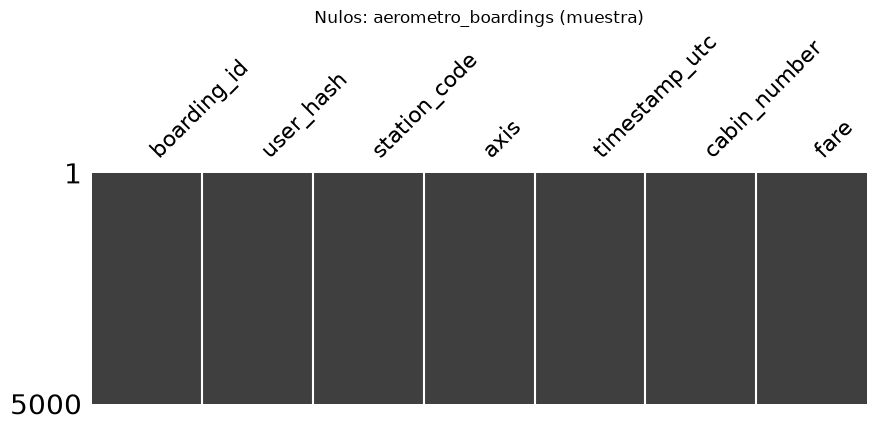


########## Semántica: aerometro_boardings ##########

[fecha/hora] timestamp_utc  |  ejemplos: ['2026-06-01T22:04:15Z', '2026-06-01T15:27:06Z', '2026-06-01T21:04:01Z']
  no parseables: 0  |  min: 2026-06-01 10:00:17+00:00  |  max: 2026-07-16 04:59:56+00:00
  ¿trae componente hora?: True
  formas: {'9999-99-99A99:99:99A': 203554}

[llave] user_hash  |  ejemplos: ['e1f5e4512ced', '8a9b5528302f', 'bb717d245929']  |  distintas: 14496
  formas: {'999999999999': 647, '9999999999A9': 590, '99999999999A': 583, '999A99999999': 564, '99999A999999': 559}
  longitudes: {12: 203554}

[dinero] fare  |  ejemplos: ['3.50', '3.50', '3.50']
  no numéricos: 0  |  min 3.5  mediana 3.5  max 3.5  |  con decimales: True


In [36]:
am = leer_csv("aerometro_boardings")
display(am.head(8))
perfilar(am, "aerometro_boardings")
matriz_nulos(am, "aerometro_boardings")
explorar_semantica(am, "aerometro_boardings")

In [37]:
# Aerómetro: ¿el string de fecha lleva sufijo de zona horaria (Z, +00:00)? Esto se documenta, no se convierte en Bronze.
for c in candidatas(am, "fecha/hora"):
    s = am[c].dropna().astype(str)
    print(c, "| termina en Z:", s.str.endswith("Z").mean().round(4),
          "| tiene offset +/-HH:MM:", s.str.contains(r"[+-]\d{2}:?\d{2}$").mean().round(4))

timestamp_utc | termina en Z: 1.0 | tiene offset +/-HH:MM: 0.0


## 5. MetroRiel (`metroriel_viajes.jsonl`)

Decisiones que se cierran aquí: qué rutas tiene el JSON, qué tan anidado es, si hay **deriva de esquema** (rutas que no aparecen en todos
los registros), si hay listas, y si el campo de fecha ISO 8601 **incluye hora** (define la partición y el análisis de horas pico).

In [29]:
def aplanar(obj, ruta=""):
    """Genera (ruta, tipo, valor) para cada hoja del JSON. Las listas se marcan con '[]'."""
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield from aplanar(v, f"{ruta}.{k}" if ruta else k)
    elif isinstance(obj, list):
        yield ruta, "list", len(obj)
        for el in obj:
            yield from aplanar(el, f"{ruta}[]")
    else:
        yield ruta, type(obj).__name__, obj

p_mr = DATA_DIR / ARCHIVOS["metroriel_viajes"]
registros, malos, vacias = [], [], 0
with open(p_mr, encoding="utf-8-sig") as f:
    for n, linea in enumerate(f, 1):
        if not linea.strip():
            vacias += 1
            continue
        try:
            registros.append(json.loads(linea))
        except json.JSONDecodeError as e:
            malos.append((n, str(e)[:70]))
        if len(registros) >= MUESTRA_JSON:
            break

print(f"Registros JSON válidos leídos: {len(registros):,}  |  líneas vacías: {vacias}  |  líneas con JSON inválido: {len(malos)}")
print("Primeras líneas inválidas:", malos[:5])
print("\nPrimer registro:")
print(json.dumps(registros[0], indent=2, ensure_ascii=False))

Registros JSON válidos leídos: 200,000  |  líneas vacías: 0  |  líneas con JSON inválido: 0
Primeras líneas inválidas: []

Primer registro:
{
  "trip_id": 1,
  "card": "MR0041900",
  "entry": {
    "station": 12,
    "ts": "2026-06-01T19:11:11"
  },
  "exit": {
    "station": 15,
    "ts": "2026-06-01T19:23:31"
  },
  "fare_gtq": 3.0,
  "duration_s": 740
}


In [30]:
# Rutas del JSON: presencia, tipos y ejemplos. Presencia < 100 % = deriva de esquema / campos opcionales.
presencia, tipos, ejemplos = Counter(), {}, {}
for r in registros:
    vistas = set()
    for ruta, tipo, valor in aplanar(r):
        vistas.add(ruta)
        tipos.setdefault(ruta, Counter())[tipo] += 1
        ejemplos.setdefault(ruta, valor)
    presencia.update(vistas)

rutas = pd.DataFrame({
    "ruta": list(presencia),
    "presencia_%": [round(presencia[k] / len(registros) * 100, 2) for k in presencia],
    "tipos": [dict(tipos[k]) for k in presencia],
    "ejemplo": [ejemplos[k] for k in presencia],
}).sort_values("ruta").reset_index(drop=True)
display(rutas)

print("Profundidad máxima de anidamiento:", max(r.count(".") for r in rutas["ruta"]))
print("Rutas con listas:", [r for r in rutas["ruta"] if "[]" in r or "list" in str(rutas.loc[rutas['ruta'] == r, 'tipos'].iloc[0])])
print("Rutas opcionales (presencia < 100 %):", rutas.loc[rutas["presencia_%"] < 100, "ruta"].tolist())
print("Rutas con más de un tipo (p. ej. número y texto):",
      rutas.loc[rutas["tipos"].apply(len) > 1, "ruta"].tolist())

,ruta,presencia_%,tipos,ejemplo
0,card,100.00,{'str': 200000},MR0041900
1,duration_s,100.00,"{'int': 197565, 'NoneType': 2435}",740
2,entry.station,100.00,{'int': 200000},12
3,entry.ts,100.00,{'str': 200000},2026-06-01T19:11:11
4,exit,1.22,{'NoneType': 2435},None
5,exit.station,98.78,{'int': 197565},15
6,exit.ts,98.78,{'str': 197565},2026-06-01T19:23:31
7,fare_gtq,100.00,{'float': 200000},3.0
8,trip_id,100.00,{'int': 200000},1


Profundidad máxima de anidamiento: 1
Rutas con listas: []
Rutas opcionales (presencia < 100 %): ['exit', 'exit.station', 'exit.ts']
Rutas con más de un tipo (p. ej. número y texto): ['duration_s']


In [31]:
# Campos de fecha/hora, llaves y dinero de MetroRiel (por nombre de ruta)
def rutas_que_coinciden(tipo):
    return [r for r in rutas["ruta"] if re.search(PATRONES[tipo], r, flags=re.I)]

df_mr = pd.json_normalize(registros[:100_000])
for tipo in ["fecha/hora", "llave usuario", "dinero", "zona"]:
    for c in rutas_que_coinciden(tipo):
        if c not in df_mr.columns:
            continue
        s = df_mr[c].astype("string")
        print(f"\n[{tipo}] {c}  |  ejemplos: {s.dropna().head(3).tolist()}")
        print("  formas:", patron_formato(s, 5).to_dict())
        if tipo == "fecha/hora":
            p = parsear_fecha(s)
            print(f"  no parseables: {(p.isna() & s.notna()).sum()}  |  min: {p.min()}  |  max: {p.max()}")
            print(f"  ¿trae componente hora?: {(p.dt.hour.fillna(0) != 0).any() if p.notna().any() else 'n/d'}")
            patron_offset = r"Z$|[+-]\d{2}:?\d{2}$"
            print(f"  ¿sufijo Z / offset?: {s.str.contains(patron_offset).mean():.2%}")
    


[llave usuario] card  |  ejemplos: ['MR0041900', 'MR0027470', 'MR0034691']
  formas: {'AA9999999': 100000}

[dinero] fare_gtq  |  ejemplos: ['3.0', '3.0', '3.0']
  formas: {'9.9': 100000}


In [32]:
# Perfil de nulos del JSON aplanado (equivalente a los pasos del lab de referencia)
print("Shape:", df_mr.shape)
print("\nDtypes:")
print(df_mr.dtypes)
print("\nNulos por columna:")
print(df_mr.isna().sum())
pct_nulos = (df_mr.isna().sum() / len(df_mr) * 100).round(2)
print("\n% de nulos por columna:")
print(pct_nulos.sort_values(ascending=False))
print("\nInfo general:")
df_mr.info()

Shape: (100000, 9)

Dtypes:
trip_id            int64
card                 str
fare_gtq         float64
duration_s       float64
entry.station      int64
entry.ts             str
exit.station     float64
exit.ts              str
exit             float64
dtype: object

Nulos por columna:
trip_id               0
card                  0
fare_gtq              0
duration_s         1211
entry.station         0
entry.ts              0
exit.station       1211
exit.ts            1211
exit             100000
dtype: int64

% de nulos por columna:
exit             100.00
exit.station       1.21
duration_s         1.21
exit.ts            1.21
trip_id            0.00
entry.station      0.00
fare_gtq           0.00
card               0.00
entry.ts           0.00
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   trip_id        10000

In [33]:
# ¿Se pierde formato al parsear? Compara el texto original de una línea con lo que devuelve json.loads
# (por ejemplo 12.50 -> 12.5). Justifica guardar también una columna _raw_json en Bronze.
import itertools
with open(p_mr, encoding="utf-8-sig") as f:
    for linea in itertools.islice(f, 3):
        original = linea.strip()
        reserializado = json.dumps(json.loads(linea), ensure_ascii=False, separators=(",", ":"))
        print("Idéntico tras parsear/serializar:", original.replace(" ", "") == reserializado.replace(" ", ""))
        if original.replace(" ", "") != reserializado.replace(" ", ""):
            print("  original    :", original[:200])
            print("  reserializado:", reserializado[:200])

Idéntico tras parsear/serializar: True
Idéntico tras parsear/serializar: True
Idéntico tras parsear/serializar: True


## 6. CDC del padrón (`cdc_padron_usuarios.csv`)

Es el archivo que más decisiones define. Hay que identificar: **columna de operación**, **columna de secuencia/timestamp**,
**llave de tarjeta**, si el archivo viene **ordenado**, y qué patrón de operaciones sigue cada tarjeta.

> El enunciado habla de INSERT, UPDATE y DELETE en un párrafo y de "DELETED" en otro. Aquí se detecta por prefijo para cubrir ambos.

,seq,commit_ts,op,tarjeta,perfil,zona_residencia,estado
0,1,2026-06-01T08:50:00,INSERT,TC-00029030,trabajador,Zona 12,ACTIVA
1,2,2026-06-01T16:51:00,INSERT,SIN-TARJETA,trabajador,Villa Nueva,ACTIVA
2,3,2026-06-01T14:20:00,INSERT,TC-00051500,estudiante,Zona 13,ACTIVA
3,4,2026-06-01T06:31:00,INSERT,TC-00041197,general,Zona 11,ACTIVA
4,5,2026-06-01T23:34:00,INSERT,TC-00019513,adulto_mayor,Zona 1,ACTIVA
5,6,2026-06-01T15:47:00,INSERT,SIN-TARJETA,general,Zona 8,ACTIVA
6,7,2026-06-01T04:53:00,INSERT,MR0055590,adulto_mayor,Zona 6,ACTIVA
7,8,2026-06-01T03:54:00,INSERT,TC-00048976,estudiante,Zona 18,ACTIVA
8,9,2026-06-01T16:25:00,INSERT,MR0005006,adulto_mayor,Zona 1,ACTIVA
9,10,2026-06-01T23:23:00,INSERT,TC-00026567,general,Zona 17,ACTIVA


===== cdc_padron_usuarios =====
Shape: (31050, 7)

Dtypes (leído como texto) vs. dtype que pandas inferiría:
                leido inferido
seq               str    int64
commit_ts         str      str
op                str      str
tarjeta           str      str
perfil            str      str
zona_residencia   str      str
estado            str      str

Nulos por columna:
seq                   0
commit_ts             0
op                    0
tarjeta               0
perfil             4050
zona_residencia    4050
estado             4050
dtype: int64

% de nulos por columna:
estado             13.04
zona_residencia    13.04
perfil             13.04
op                  0.00
commit_ts           0.00
seq                 0.00
tarjeta             0.00
dtype: float64

Info general:
<class 'pandas.DataFrame'>
RangeIndex: 31050 entries, 0 to 31049
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   seq              31050

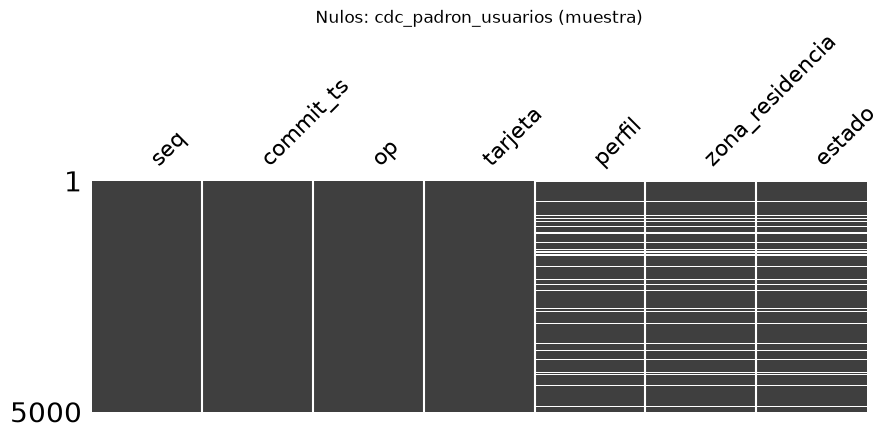

In [20]:
cdc = leer_csv("cdc_padron_usuarios")
display(cdc.head(10))
perfilar(cdc, "cdc_padron_usuarios")
matriz_nulos(cdc, "cdc_padron_usuarios")

In [21]:
# Detección automática de la columna de operación (la que contiene INSERT/UPDATE/DELETE)
muestra = cdc.head(100_000)
cand_op = [c for c in cdc.columns
           if muestra[c].dropna().astype(str).str.upper().str.contains(r"^(?:INSERT|UPDATE|DELETE)").mean() > 0.9]
cand_seq = [c for c in cdc.columns if re.search(r"seq|lsn|scn|secuencia|ts|time|fecha|version|orden|change", c, flags=re.I)]
cand_key = candidatas(cdc, "llave usuario")

print("Candidatas columna de operación :", cand_op)
print("Candidatas secuencia/timestamp  :", cand_seq)
print("Candidatas llave de tarjeta     :", cand_key)

Candidatas columna de operación : ['op']
Candidatas secuencia/timestamp  : ['seq', 'commit_ts']
Candidatas llave de tarjeta     : ['tarjeta']


In [22]:
# ===== AJUSTAR: fija los nombres definitivos después de mirar las candidatas =====
COL_OP  = cand_op[0]  if cand_op  else None
COL_SEQ = cand_seq[0] if cand_seq else None
COL_KEY = cand_key[0] if cand_key else None
# COL_OP, COL_SEQ, COL_KEY = "operacion", "secuencia", "llave_usuario"

print("COL_OP =", COL_OP, "| COL_SEQ =", COL_SEQ, "| COL_KEY =", COL_KEY)
assert all([COL_OP, COL_SEQ, COL_KEY]), "Fija COL_OP, COL_SEQ y COL_KEY manualmente"

cdc["_op"] = cdc[COL_OP].str.upper().str.extract(r"^(INSERT|UPDATE|DELETE)", expand=False)
print("\nValores originales de la columna de operación:", cdc[COL_OP].value_counts(dropna=False).to_dict())
print("Operaciones no reconocidas:", cdc["_op"].isna().sum())

COL_OP = op | COL_SEQ = seq | COL_KEY = tarjeta

Valores originales de la columna de operación: {'UPDATE': 16200, 'INSERT': 10800, 'DELETE': 4050}
Operaciones no reconocidas: 0


In [23]:
# ¿La secuencia es numérica o es un timestamp? ¿única? ¿el archivo viene ordenado?
def a_orden(s):
    n = pd.to_numeric(s, errors="coerce")
    if n.notna().mean() > 0.99:
        return n, "numérica"
    return parsear_fecha(s), "timestamp"

def fuera_de_orden(s):
    """Filas donde el valor es menor que el anterior (funciona para numérico y datetime)."""
    d = s.diff()
    if pd.api.types.is_timedelta64_dtype(d):
        return int((d < pd.Timedelta(0)).sum())
    return int((d < 0).sum())

cdc["_seq"], tipo_seq = a_orden(cdc[COL_SEQ])
print("Tipo de secuencia:", tipo_seq, "| ejemplos:", cdc[COL_SEQ].head(3).tolist())
print("Secuencias nulas o no parseables:", cdc["_seq"].isna().sum())
print("Secuencias duplicadas:", cdc["_seq"].duplicated().sum())
print("¿Orden creciente en el archivo?:", cdc["_seq"].is_monotonic_increasing)
print("Filas fuera de orden respecto a la anterior:", (cdc["_seq"].diff() < 0).sum())
print("Rango:", cdc["_seq"].min(), "→", cdc["_seq"].max())

Tipo de secuencia: numérica | ejemplos: ['1', '2', '3']
Secuencias nulas o no parseables: 0
Secuencias duplicadas: 0
¿Orden creciente en el archivo?: True
Filas fuera de orden respecto a la anterior: 0
Rango: 1 → 31050


In [24]:
# Comparar las dos candidatas a orden: seq vs commit_ts
cdc["_seq"], tipo_seq = a_orden(cdc["seq"])
cdc["_ts"],  tipo_ts  = a_orden(cdc["commit_ts"])
print("seq       :", tipo_seq, "| ejemplos:", cdc["seq"].head(3).tolist())
print("commit_ts :", tipo_ts,  "| ejemplos:", cdc["commit_ts"].head(3).tolist())

for nombre, col in [("seq", "_seq"), ("commit_ts", "_ts")]:
    s = cdc[col]
    print(f"\n{nombre}: nulos={s.isna().sum()} | duplicados={s.duplicated().sum()} | "
          f"creciente en el archivo={s.is_monotonic_increasing} | "
          f"filas fuera de orden={fuera_de_orden(s)}")

# Empates de commit_ts dentro de la MISMA tarjeta:
# si existen, commit_ts solo no puede ordenar sus operaciones.
print("\nMisma tarjeta + mismo commit_ts:", int(cdc.duplicated([COL_KEY, "_ts"]).sum()))
print("Misma tarjeta + mismo seq      :", int(cdc.duplicated([COL_KEY, "_seq"]).sum()))

# ¿Los dos órdenes producen el mismo resultado?
def ops_por_tarjeta(orden):
    d = cdc.sort_values(orden, kind="stable")
    g = d.groupby(COL_KEY)["_op"]
    return g.agg(">".join), g.last()

pat_seq, ult_seq = ops_por_tarjeta(["_seq"])
pat_ts,  ult_ts  = ops_por_tarjeta(["_ts", "_seq"])

print("\nTarjetas con distinta secuencia de operaciones:",
      int((pat_seq != pat_ts.reindex(pat_seq.index)).sum()))
print("Tarjetas con distinta última operación        :",
      int((ult_seq != ult_ts.reindex(ult_seq.index)).sum()))

# Anomalías bajo cada orden (un orden correcto no debería producirlas)
def anomalias(pat):
    return {
        "sin INSERT inicial":           int((~pat.str.startswith("INSERT")).sum()),
        "operación posterior a DELETE": int(pat.str.contains(r"DELETE>(?:INSERT|UPDATE)").sum()),
        "más de un DELETE":             int((pat.str.count("DELETE") > 1).sum()),
    }
print("\nAnomalías ordenando por seq      :", anomalias(pat_seq))
print("Anomalías ordenando por commit_ts:", anomalias(pat_ts))

seq       : numérica | ejemplos: ['1', '2', '3']
commit_ts : timestamp | ejemplos: ['2026-06-01T08:50:00', '2026-06-01T16:51:00', '2026-06-01T14:20:00']

seq: nulos=0 | duplicados=0 | creciente en el archivo=True | filas fuera de orden=0

commit_ts: nulos=0 | duplicados=6383 | creciente en el archivo=False | filas fuera de orden=15479

Misma tarjeta + mismo commit_ts: 33
Misma tarjeta + mismo seq      : 0

Tarjetas con distinta secuencia de operaciones: 58
Tarjetas con distinta última operación        : 42

Anomalías ordenando por seq      : {'sin INSERT inicial': 14617, 'operación posterior a DELETE': 655, 'más de un DELETE': 141}
Anomalías ordenando por commit_ts: {'sin INSERT inicial': 14662, 'operación posterior a DELETE': 673, 'más de un DELETE': 141}


In [25]:
# Los DELETE llegan con la llave y sin cuerpo: verificar qué columnas vienen vacías
resto = [c for c in cdc.columns if c not in {COL_OP, COL_SEQ, COL_KEY, "_op", "_seq"}]
print("Conteo por operación:")
print(cdc["_op"].value_counts(dropna=False))

print("\n% de nulos por operación y columna del cuerpo:")
display((cdc.groupby("_op")[resto].apply(lambda g: g.isna().mean() * 100)).round(1))

d = cdc[cdc["_op"] == "DELETE"]
print("DELETE con alguna columna de cuerpo con valor:", d[resto].notna().any(axis=1).sum(), "de", len(d))

Conteo por operación:
_op
UPDATE    16200
INSERT    10800
DELETE     4050
Name: count, dtype: int64

% de nulos por operación y columna del cuerpo:


,commit_ts,perfil,zona_residencia,estado,_ts
_op,,,,,
DELETE,0.0,100.0,100.0,100.0,0.0
INSERT,0.0,0.0,0.0,0.0,0.0
UPDATE,0.0,0.0,0.0,0.0,0.0


DELETE con alguna columna de cuerpo con valor: 4050 de 4050


In [26]:
# Patrón de operaciones por tarjeta, ordenado por secuencia
por_llave = (cdc.sort_values("_seq", kind="stable")
                .groupby(COL_KEY)["_op"].agg(lambda s: ">".join(s)))
print("Tarjetas distintas:", por_llave.shape[0])
print("\nPatrones de operaciones por tarjeta (top 15):")
print(por_llave.value_counts().head(15))

anomalias = {
    "sin INSERT inicial":           por_llave[~por_llave.str.startswith("INSERT")].shape[0],
    "INSERT repetido":              por_llave[por_llave.str.count("INSERT") > 1].shape[0],
    "operación posterior a DELETE": por_llave[por_llave.str.contains(r"DELETE>(?:INSERT|UPDATE)")].shape[0],
    "más de un DELETE":             por_llave[por_llave.str.count("DELETE") > 1].shape[0],
}
print("\nAnomalías:", anomalias)

Tarjetas distintas: 22463

Patrones de operaciones por tarjeta (top 15):
_op
UPDATE                  8941
INSERT                  5918
DELETE                  2219
UPDATE>UPDATE           1228
INSERT>UPDATE            833
UPDATE>INSERT            770
INSERT>INSERT            560
UPDATE>DELETE            348
DELETE>UPDATE            282
INSERT>DELETE            222
DELETE>INSERT            188
UPDATE>UPDATE>UPDATE     120
DELETE>DELETE             91
UPDATE>INSERT>UPDATE      74
UPDATE>UPDATE>INSERT      70
Name: count, dtype: int64

Anomalías: {'sin INSERT inicial': 14617, 'INSERT repetido': 828, 'operación posterior a DELETE': 655, 'más de un DELETE': 141}


In [27]:
# Vista previa del "antes / después" de aplicar los borrados (solo exploración; el entregable se calcula en staging)
ultimo = (cdc.sort_values("_seq", kind="stable").groupby(COL_KEY).tail(1))
antes = cdc[COL_KEY].nunique()
bajas = (ultimo["_op"] == "DELETE").sum()
print(f"Tarjetas distintas en el log : {antes:,}")
print(f"Tarjetas cuya última op es DELETE (dadas de baja): {bajas:,}")
print(f"Tarjetas activas (vista previa)                   : {antes - bajas:,}")

Tarjetas distintas en el log : 22,463
Tarjetas cuya última op es DELETE (dadas de baja): 2,994
Tarjetas activas (vista previa)                   : 19,469


## 7. Llaves de usuario y mapeo entre fuentes

### 7.1 Columnas definitivas y lectura completa de MetroRiel

In [34]:
# Columnas fijas según las secciones 4 y 5
COL_KEY_TM, COL_KEY_TU, COL_KEY_AM = "tarjeta", "num_tarjeta", "user_hash"
COL_KEY_MR = "card"

# MetroRiel COMPLETO: la sección 5 solo leyó MUESTRA_JSON y df_mr solo 100 000 filas.
filas_mr, malos_mr = [], []
with open(p_mr, encoding="utf-8-sig") as fh:
    for n, linea in enumerate(fh, 1):
        if not linea.strip():
            continue
        try:
            r = json.loads(linea)
        except json.JSONDecodeError:
            malos_mr.append(n)
            continue
        e, x = r.get("entry") or {}, r.get("exit") or {}
        filas_mr.append((r.get("trip_id"), r.get("card"), e.get("station"), e.get("ts"),
                         x.get("station"), x.get("ts"), r.get("duration_s"), r.get("fare_gtq")))

mr = pd.DataFrame(filas_mr, columns=["trip_id", "card", "entry_station", "entry_ts",
                                     "exit_station", "exit_ts", "duration_s", "fare_gtq"])
for c in ["card", "entry_ts", "exit_ts"]:
    mr[c] = mr[c].astype("string")
# Enteros anulables: evita que exit_station (con nulos) se convierta en float (15 -> 15.0)
for c in ["trip_id", "entry_station", "exit_station", "duration_s"]:
    mr[c] = pd.to_numeric(mr[c], errors="coerce").astype("Int64")

print(f"MetroRiel completo: {len(mr):,} viajes | líneas JSON inválidas: {len(malos_mr)}")
print(f"Viajes sin salida (exit nulo): {mr['exit_ts'].isna().sum():,} ({mr['exit_ts'].isna().mean():.2%})")
print("duration_s nulo coincide con exit nulo:", bool((mr['duration_s'].isna() == mr['exit_ts'].isna()).all()))

MetroRiel completo: 299,100 viajes | líneas JSON inválidas: 0
Viajes sin salida (exit nulo): 3,589 (1.20%)
duration_s nulo coincide con exit nulo: True


### 7.2 Calidad y formato de la llave por operador

In [38]:
FORMATOS = {
    "transmetro":  (tm[COL_KEY_TM],  r"TC-\d{8}"),
    "transurbano": (tu[COL_KEY_TU],  r"\d{10}"),
    "metroriel":   (mr[COL_KEY_MR],  r"MR\d{7}"),
    "aerometro":   (am[COL_KEY_AM],  r"[0-9a-f]{12}"),
}

filas = []
for nombre, (s, patron) in FORMATOS.items():
    s = s.astype("string")
    limpia = s.dropna().str.strip()
    filas.append({
        "fuente": nombre,
        "filas": len(s),
        "nulas": int(s.isna().sum()),
        "distintas": s.nunique(),
        "distintas_strip_upper": limpia.str.upper().nunique(),
        "con_espacios": int((s.dropna() != limpia).sum()),
        "formato_esperado_%": round(limpia.str.fullmatch(patron).mean() * 100, 3),
    })
calidad_llaves = pd.DataFrame(filas).set_index("fuente")
display(calidad_llaves)
print("• 'distintas' ≠ 'distintas_strip_upper' → hay variantes de una misma llave.")
print("• 'formato_esperado_%' < 100 → hay llaves fuera de patrón (candidatas a cuarentena en Silver).")

,filas,nulas,distintas,distintas_strip_upper,con_espacios,formato_esperado_%
fuente,,,,,,
transmetro,363221,0,43255,43255,0,100.0
transurbano,832791,0,36567,36567,0,100.0
metroriel,299100,0,22885,22885,0,100.0
aerometro,203554,0,14496,14496,0,100.0


• 'distintas' ≠ 'distintas_strip_upper' → hay variantes de una misma llave.
• 'formato_esperado_%' < 100 → hay llaves fuera de patrón (candidatas a cuarentena en Silver).


### 7.3 Id de evento y duplicados

Cada fuente necesita una clave para detectar duplicados en Silver. Transurbano **no trae id de evento**, por eso la llave técnica de Bronze
(`_file_hash` + `_source_line_number`) es la única garantía de idempotencia para ese archivo.

In [39]:
def revisar_id_evento(df, col, nombre):
    exactas = int(df.duplicated().sum())
    if col is None:
        return {"fuente": nombre, "id_evento": "(ninguno)", "filas": len(df), "ids_repetidos": None,
                "filas_duplicadas_exactas": exactas, "ids_con_contenido_distinto": None}
    ids_rep = int(df[col].duplicated().sum())
    rep = df[df[col].duplicated(keep=False)].drop_duplicates()
    conflictos = int((rep.groupby(col).size() > 1).sum()) if len(rep) else 0
    return {"fuente": nombre, "id_evento": col, "filas": len(df), "ids_repetidos": ids_rep,
            "filas_duplicadas_exactas": exactas, "ids_con_contenido_distinto": conflictos}

ids_evento = pd.DataFrame([
    revisar_id_evento(tm, "validacion_id", "transmetro"),
    revisar_id_evento(tu, None,            "transurbano"),
    revisar_id_evento(am, "boarding_id",   "aerometro"),
    revisar_id_evento(mr, "trip_id",       "metroriel"),
]).set_index("fuente")
ids_evento[["ids_repetidos", "ids_con_contenido_distinto"]] = ids_evento[["ids_repetidos", "ids_con_contenido_distinto"]].astype("Int64")
display(ids_evento)
print("• ids_repetidos = filas_duplicadas_exactas y conflictos = 0 → son copias completas; Silver deduplica por id, Bronze las conserva.")
print("• ids_con_contenido_distinto > 0 → mismo id con datos distintos: caso para cuarentena con motivo.")

,id_evento,filas,ids_repetidos,filas_duplicadas_exactas,ids_con_contenido_distinto
fuente,,,,,
transmetro,validacion_id,363221,1115,1115,0
transurbano,(ninguno),832791,<NA>,0,<NA>
aerometro,boarding_id,203554,0,0,0
metroriel,trip_id,299100,0,0,0


• ids_repetidos = filas_duplicadas_exactas y conflictos = 0 → son copias completas; Silver deduplica por id, Bronze las conserva.
• ids_con_contenido_distinto > 0 → mismo id con datos distintos: caso para cuarentena con motivo.


### 7.4 Padrón (CDC) vs. validaciones de Transmetro

El CDC tiene 10,800 INSERT, pero las validaciones tienen 43,255 tarjetas distintas. Si cada tarjeta se inserta una vez, la mayoría de las tarjetas que viajan
**no existen en el padrón**. Esta celda lo mide. Es un dato central para Silver: esas validaciones no se descartan, y el tratamiento se decide con la cifra en mano.

In [40]:
COL_KEY_CDC = COL_KEY   # definida en la sección 6
val = set(tm[COL_KEY_TM].dropna().unique())
pad = set(cdc[COL_KEY_CDC].dropna().unique())

print(f"Tarjetas distintas en validaciones: {len(val):,} | en el CDC: {len(pad):,}")
print(f"En ambos: {len(val & pad):,} | solo en validaciones (sin padrón): {len(val - pad):,} | solo en padrón (sin viajes): {len(pad - val):,}")
print(f"% de tarjetas de validaciones con registro en el padrón: {len(val & pad) / len(val):.1%}")

sin_padron = ~tm[COL_KEY_TM].isin(pad)
print(f"Filas de validaciones sin padrón: {sin_padron.sum():,} ({sin_padron.mean():.1%})")

# Además: ¿hay validaciones de tarjetas cuya última operación es DELETE?
ultimo = cdc.sort_values("_seq", kind="stable").groupby(COL_KEY_CDC).tail(1)
bajas = set(ultimo.loc[ultimo["_op"] == "DELETE", COL_KEY_CDC])
print(f"Validaciones de tarjetas dadas de baja: {tm[COL_KEY_TM].isin(bajas).sum():,}  (historial que se pierde si se borran)")

Tarjetas distintas en validaciones: 43,255 | en el CDC: 22,463
En ambos: 17,430 | solo en validaciones (sin padrón): 25,825 | solo en padrón (sin viajes): 5,033
% de tarjetas de validaciones con registro en el padrón: 40.3%
Filas de validaciones sin padrón: 216,565 (59.6%)
Validaciones de tarjetas dadas de baja: 19,526  (historial que se pierde si se borran)


### 7.5 ¿Comparten identidad las llaves de los operadores? (hipótesis, no conclusión)

El enunciado muestra `TC-00012345`, `0000012345` y `MR0012345`: la misma parte numérica en tres formatos. Puede ser un diseño del generador o una simple coincidencia de rangos.
Coincidir numéricamente **no prueba** que sea la misma persona, así que esta celda solo mide el solapamiento.
La evidencia definitiva está en `generar_red_metropolitana.py`: busca cómo se generan `tarjeta`, `num_tarjeta`, `card` y `user_hash`.

In [42]:
from itertools import combinations

def parte_numerica(s):
    extraido = s.astype("string").str.extract(r"(\d+)")[0]
    return set(extraido.dropna().astype(int))
    
nums = {
    "transmetro":  parte_numerica(tm[COL_KEY_TM]),
    "padron_cdc":  parte_numerica(cdc[COL_KEY_CDC]),
    "transurbano": parte_numerica(tu[COL_KEY_TU]),
    "metroriel":   parte_numerica(mr[COL_KEY_MR]),
}
print("Rango de la parte numérica:")
for k, v in nums.items():
    print(f"  {k:12s} distintos={len(v):>7,}  min={min(v):>6}  max={max(v):>6}")

print("\nSolapamiento:")
for a, b in combinations(nums, 2):
    inter = nums[a] & nums[b]
    print(f"  {a:12s} ∩ {b:12s}: {len(inter):>7,}  ({len(inter) / min(len(nums[a]), len(nums[b])):.1%} del conjunto menor)")

Rango de la parte numérica:
  transmetro   distintos= 43,255  min=     1  max= 60000
  padron_cdc   distintos= 22,462  min=     1  max= 59998
  transurbano  distintos= 36,567  min=     2  max= 60000
  metroriel    distintos= 22,885  min=     2  max= 59999

Solapamiento:
  transmetro   ∩ padron_cdc  :  17,430  (77.6% del conjunto menor)
  transmetro   ∩ transurbano :  26,401  (72.2% del conjunto menor)
  transmetro   ∩ metroriel   :  16,515  (72.2% del conjunto menor)
  padron_cdc   ∩ transurbano :  14,637  (65.2% del conjunto menor)
  padron_cdc   ∩ metroriel   :   9,213  (41.0% del conjunto menor)
  transurbano  ∩ metroriel   :  13,903  (60.8% del conjunto menor)


In [43]:
# Aerómetro: ¿user_hash es un hash de alguna de las representaciones del id? Si ninguna coincide, el hash es opaco y no vinculable.
import hashlib
hashes_am = set(am[COL_KEY_AM])
aciertos = Counter()
for n in range(1, 100_001):
    formas = {"n": str(n), "TC-8": f"TC-{n:08d}", "10d": f"{n:010d}", "MR7": f"MR{n:07d}", "8d": f"{n:08d}"}
    for etiqueta, texto in formas.items():
        for alg in ("md5", "sha1", "sha256"):
            if hashlib.new(alg, texto.encode()).hexdigest()[:12] in hashes_am:
                aciertos[f"{alg}({etiqueta})"] += 1
print(aciertos.most_common(5) if aciertos else
      "Ninguna variante coincide: user_hash es opaco. No se puede vincular con los otros operadores (se documenta, no se inventa).")

Ninguna variante coincide: user_hash es opaco. No se puede vincular con los otros operadores (se documenta, no se inventa).


### 7.6 Valores de dominio (columnas de pocas categorías)

In [44]:
# Dominios cerrados: sirven para definir pruebas dbt (accepted_values) y detectar códigos raros
for nombre, df in {"transmetro": tm, "transurbano": tu, "aerometro": am, "metroriel": mr}.items():
    for c in df.columns:
        if df[c].nunique(dropna=False) <= 20:
            print(f"{nombre}.{c}: {df[c].value_counts(dropna=False).to_dict()}")

transmetro.linea: {'L18': 45561, 'L2': 45488, 'L7': 45485, 'L6': 45376, 'L1': 45363, 'L13': 45354, 'R5': 45334, 'L12': 45260}
transmetro.tarifa: {'1.00': 264990, '0.50': 64667, '0.00': 33564}
transmetro.tipo: {'ENTRADA': 272509, 'TRANSBORDO': 90712}
transurbano.monto_centavos: {'130': 682634, '65': 150157}
transurbano.cod_estado: {'1': 333327, '2': 332745, '3': 125070, '7': 33318, '9': 8331}
aerometro.station_code: {'AM15': 14772, 'AM22': 14759, 'AM25': 14663, 'AM13': 14614, 'AM14': 14599, 'AM21': 14579, 'AM27': 14510, 'AM17': 14500, 'AM26': 14483, 'AM23': 14470, 'AM12': 14445, 'AM11': 14436, 'AM24': 14412, 'AM16': 14312}
aerometro.axis: {'Eje 2': 101876, 'Eje 1': 101678}
aerometro.cabin_number: {'5': 20549, '1': 20489, '8': 20435, '2': 20372, '10': 20370, '6': 20350, '9': 20347, '3': 20289, '7': 20269, '4': 20084}
aerometro.fare: {'3.50': 203554}
metroriel.fare_gtq: {3.0: 245509, 1.5: 53591}


### 7.7 Llaves de estación/parada vs. catálogos

Ninguno de los cuatro operativos trae zona: la zona vive en los catálogos. Antes de Silver hay que saber si cada `estacion_id` / `cod_parada` / `station_code` / `entry.station`
existe en su catálogo. Se detecta automáticamente la columna del catálogo con mayor coincidencia.

In [45]:
def mejor_columna_catalogo(serie, cat):
    valores = set(serie.dropna().astype(str).unique())
    res = {c: len(valores & set(cat[c].dropna().astype(str))) / max(len(valores), 1) for c in cat.columns}
    c = max(res, key=res.get)
    huerfanas = sorted(valores - set(cat[c].dropna().astype(str)))
    return c, res[c], huerfanas

pares = {
    "transmetro.estacion_id":   (tm["estacion_id"],    catalogos["tm_estaciones"]),
    "transurbano.cod_parada":   (tu["cod_parada"],     catalogos["tu_paradas"]),
    "aerometro.station_code":   (am["station_code"],   catalogos["am_estaciones"]),
    "metroriel.entry_station":  (mr["entry_station"],  catalogos["mr_estaciones"]),
    "metroriel.exit_station":   (mr["exit_station"],   catalogos["mr_estaciones"]),
}
filas = []
for nombre, (serie, cat) in pares.items():
    col, cob, huerf = mejor_columna_catalogo(serie, cat)
    filas.append({"llave_operativa": nombre, "columna_catalogo": col, "cobertura_%": round(cob * 100, 1),
                  "huerfanas": len(huerf), "ejemplos_huerfanas": huerf[:5]})
display(pd.DataFrame(filas).set_index("llave_operativa"))
print("• cobertura < 100 % → llaves de estación sin catálogo (cuarentena con motivo en Silver).")
print("• Revisa a mano las columnas de zona de cada catálogo: cada uno la escribe distinto.")

,columna_catalogo,cobertura_%,huerfanas,ejemplos_huerfanas
llave_operativa,,,,
transmetro.estacion_id,estacion_id,100.0,0,[]
transurbano.cod_parada,cod_parada,100.0,0,[]
aerometro.station_code,station_code,100.0,0,[]
metroriel.entry_station,id_estacion,100.0,0,[]
metroriel.exit_station,id_estacion,100.0,0,[]


• cobertura < 100 % → llaves de estación sin catálogo (cuarentena con motivo en Silver).
• Revisa a mano las columnas de zona de cada catálogo: cada uno la escribe distinto.


### 7.8 Consistencia horaria entre operadores

Verifica que los cuatro operen en la misma ventana horaria una vez alineada la zona horaria. Solo lectura en memoria: **Bronze no convierte nada**.

,hora_min,hora_max,no_parseables
transmetro (local),4,22,0
transurbano (local),4,22,0
metroriel (local),4,22,0
aerometro (UTC crudo),0,23,0
aerometro (UTC-6),4,22,0


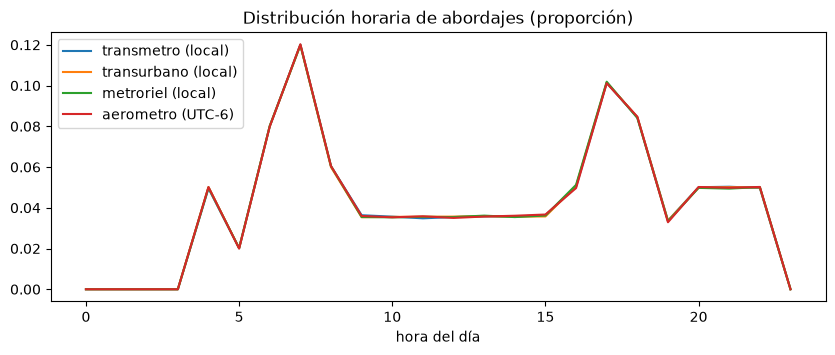

• Si 'aerometro (UTC-6)' coincide con la ventana de los demás, se confirma la regla UTC → hora local para Silver.
• Los picos de la gráfica ya anticipan el análisis de horas pico.


In [46]:
utc = pd.to_datetime(am["timestamp_utc"], utc=True, errors="coerce")
horas = {
    "transmetro (local)":    pd.to_datetime(tm["fecha_hora"], format="%Y-%m-%d %H:%M:%S", errors="coerce").dt.hour,
    "transurbano (local)":   pd.to_datetime(tu["hora"], format="%H:%M:%S", errors="coerce").dt.hour,
    "metroriel (local)":     pd.to_datetime(mr["entry_ts"], format="%Y-%m-%dT%H:%M:%S", errors="coerce").dt.hour,
    "aerometro (UTC crudo)": utc.dt.hour,
    "aerometro (UTC-6)":     (utc - pd.Timedelta(hours=6)).dt.hour,
}
rango = pd.DataFrame({k: {"hora_min": v.min(), "hora_max": v.max(), "no_parseables": int(v.isna().sum())}
                      for k, v in horas.items()}).T
display(rango)

distribucion = pd.DataFrame({k: v.value_counts(normalize=True).sort_index() for k, v in horas.items()}).fillna(0)
distribucion.drop(columns="aerometro (UTC crudo)").plot(figsize=(10, 3.5), title="Distribución horaria de abordajes (proporción)")
plt.xlabel("hora del día"); plt.show()
print("• Si 'aerometro (UTC-6)' coincide con la ventana de los demás, se confirma la regla UTC → hora local para Silver.")
print("• Los picos de la gráfica ya anticipan el análisis de horas pico.")

## 8. Resumen de hallazgos (prellenado)

Prellenado con lo observado en las secciones 4 y 5. Las celdas con `POR CONFIRMAR` dependen de las secciones 3, 6 y 7.

In [49]:
hallazgos = pd.DataFrame(
    index=list(ARCHIVOS.values()),
    columns=["columna_fecha", "formato_fecha", "tiene_hora", "columna_llave", "formato_llave",
             "columna_dinero", "unidad_dinero", "columna_zona", "observaciones"],
)

hallazgos.loc["transmetro_validaciones.csv"] = [
    "fecha_hora", "YYYY-MM-DD HH:MM:SS (hora local, sin zona)", "sí", "tarjeta", "TC-99999999",
    "tarifa", "quetzales (0.00 a 1.00)", "no trae; vía estacion_id → tm_estaciones",
    "363,221 filas; 1,115 duplicadas exactas (Silver deduplica por validacion_id); columnas: validacion_id, tarjeta, estacion_id, linea, fecha_hora, tarifa, tipo"]

hallazgos.loc["transurbano_transacciones.csv"] = [
    "fecha + hora (separadas)", "DD/MM/YYYY y HH:MM:SS (confirmar con 4.2b)", "sí (columna hora)", "num_tarjeta", "9999999999 (10 dígitos, ceros a la izquierda)",
    "monto_centavos", "centavos (65 y 130)", "no trae; vía cod_parada → tu_paradas",
    "832,791 filas; sin id de evento; cod_parada nulo en 4,189 (0.5%); cod_estado con códigos 1-3 sin catálogo; pandas infiere num_tarjeta como int y pierde los ceros"]

hallazgos.loc["aerometro_boardings.csv"] = [
    "timestamp_utc", "YYYY-MM-DDTHH:MM:SSZ (UTC)", "sí", "user_hash", "12 caracteres hexadecimales",
    "fare", "quetzales (3.50)", "no trae; vía station_code → am_estaciones",
    "203,554 filas; 0 duplicadas; rango UTC 2026-06-01 10:00 → 2026-07-16 04:59 (equivale a 04:00-22:59 local, UTC-6); columnas: boarding_id, station_code, axis, cabin_number"]

hallazgos.loc["metroriel_viajes.jsonl"] = [
    "entry.ts / exit.ts", "ISO 8601 sin zona: YYYY-MM-DDTHH:MM:SS", "sí", "card", "MR9999999",
    "fare_gtq", "quetzales (3.0)", "no trae; vía entry.station / exit.station → mr_estaciones",
    "esquema estable, profundidad 1, sin listas; exit es null en ~1.2% de los viajes (viaje sin salida) y duration_s también; trip_id como id de evento"]

for k in ["tm_estaciones.csv", "tu_paradas.csv", "mr_estaciones.csv", "am_estaciones.csv"]:
    hallazgos.loc[k] = ["-", "-", "-", "-", "-", "-", "-", "POR CONFIRMAR (sección 3)", "catálogo (snapshot por fecha de ingesta)"]

hallazgos.loc["cdc_padron_usuarios.csv"] = [
    "commit_ts (y/o seq)", "POR CONFIRMAR (sección 6)", "POR CONFIRMAR", "tarjeta", "TC-99999999",
    "-", "-", "-", "31,050 filas: 10,800 INSERT, 16,200 UPDATE, 4,050 DELETE; columna de operación: op; orden: seq vs commit_ts POR CONFIRMAR"]

pd.set_option("display.max_colwidth", 120)
hallazgos

,columna_fecha,formato_fecha,tiene_hora,columna_llave,formato_llave,columna_dinero,unidad_dinero,columna_zona,observaciones
tm_estaciones.csv,-,-,-,-,-,-,-,POR CONFIRMAR (sección 3),catálogo (snapshot por fecha de ingesta)
tu_paradas.csv,-,-,-,-,-,-,-,POR CONFIRMAR (sección 3),catálogo (snapshot por fecha de ingesta)
mr_estaciones.csv,-,-,-,-,-,-,-,POR CONFIRMAR (sección 3),catálogo (snapshot por fecha de ingesta)
am_estaciones.csv,-,-,-,-,-,-,-,POR CONFIRMAR (sección 3),catálogo (snapshot por fecha de ingesta)
transmetro_validaciones.csv,fecha_hora,"YYYY-MM-DD HH:MM:SS (hora local, sin zona)",sí,tarjeta,TC-99999999,tarifa,quetzales (0.00 a 1.00),no trae; vía estacion_id → tm_estaciones,"363,221 filas; 1,115 duplicadas exactas (Silver deduplica por validacion_id); columnas: validacion_id, tarjeta, esta..."
aerometro_boardings.csv,timestamp_utc,YYYY-MM-DDTHH:MM:SSZ (UTC),sí,user_hash,12 caracteres hexadecimales,fare,quetzales (3.50),no trae; vía station_code → am_estaciones,"203,554 filas; 0 duplicadas; rango UTC 2026-06-01 10:00 → 2026-07-16 04:59 (equivale a 04:00-22:59 local, UTC-6); co..."
transurbano_transacciones.csv,fecha + hora (separadas),DD/MM/YYYY y HH:MM:SS (confirmar con 4.2b),sí (columna hora),num_tarjeta,"9999999999 (10 dígitos, ceros a la izquierda)",monto_centavos,centavos (65 y 130),no trae; vía cod_parada → tu_paradas,"832,791 filas; sin id de evento; cod_parada nulo en 4,189 (0.5%); cod_estado con códigos 1-3 sin catálogo; pandas in..."
metroriel_viajes.jsonl,entry.ts / exit.ts,ISO 8601 sin zona: YYYY-MM-DDTHH:MM:SS,sí,card,MR9999999,fare_gtq,quetzales (3.0),no trae; vía entry.station / exit.station → mr_estaciones,"esquema estable, profundidad 1, sin listas; exit es null en ~1.2% de los viajes (viaje sin salida) y duration_s tamb..."
cdc_padron_usuarios.csv,commit_ts (y/o seq),POR CONFIRMAR (sección 6),POR CONFIRMAR,tarjeta,TC-99999999,-,-,-,"31,050 filas: 10,800 INSERT, 16,200 UPDATE, 4,050 DELETE; columna de operación: op; orden: seq vs commit_ts POR CONF..."


In [50]:
# Exportar: inventario (conteos de origen) y hallazgos
inv_export = inv.drop(columns=["primera_linea"]).reset_index()
inv_export.to_csv("inventario_origen.csv", index=False)
hallazgos.to_csv("hallazgos_origen.csv")
calidad_llaves.to_csv("calidad_llaves.csv")
ids_evento.to_csv("ids_evento.csv")
inv_export[["archivo", "filas_datos", "filas_campos_distintos", "sha256"]]

,archivo,filas_datos,filas_campos_distintos,sha256
0,tm_estaciones.csv,104,0.0,4d53a95abb4f115b7da7f69db2c392e1748d6704807d81408a5e510f791624d0
1,tu_paradas.csv,328,0.0,a888a09c45189cfeac0a0577377d1b4c662923ee55f798d961f418aa2ac93b90
2,mr_estaciones.csv,22,0.0,c302ffbc6f0bdcf926c8eaaf9a5427ec5d38d482cc44431e3aeb20a8febb8e8c
3,am_estaciones.csv,14,0.0,e3acbeed8608fb9a6b9a8df87646bf5294e644aa64bd95484f1424b92ae21723
4,transmetro_validaciones.csv,363221,0.0,5f88356e427d0ec19b193f6aaafedc288d9bf3fbad1881f011a7d9ea912730d2
5,aerometro_boardings.csv,203554,0.0,898b871c6b3457b6b63a522d5dd8966e3a75bcaf215156a65c4a9d211af4cdc7
6,transurbano_transacciones.csv,832791,0.0,8ce5028499b7b6c7274fd838430e87d373065d377e5ec1f062a4fa6497083fad
7,metroriel_viajes.jsonl,299100,NaN,23feb4a3a55ce506bf34de5faf7834f9c390b7ca70499cc9fb3ec1c3650ebede
8,cdc_padron_usuarios.csv,31050,0.0,68e4d9dd258809dd4a45a0c5f9023ad6f3b5d32912e4447b9d20b9a7258de5c4


### Decisiones de Bronze: estado tras las secciones 4 y 5

- [x] **Fecha de Transmetro:** una columna `YYYY-MM-DD HH:MM:SS`, sin zona → se guarda tal cual.
- [x] **Fecha de Transurbano:** `fecha` y `hora` separadas; `fecha` en DD/MM/YYYY (**verificar con 4.2b**). Bronze conserva ambas separadas como texto; Silver las une con formato explícito.
- [x] **Fecha de Aerómetro:** `Z` en el 100 % de las filas → se documenta como UTC; la conversión a hora local es de Silver.
- [x] **Fecha de MetroRiel:** ISO 8601 con hora pero **sin zona**: `entry.ts` y `exit.ts`. Partición por los primeros 10 caracteres de `entry.ts`. Se asume hora local igual que Transmetro (7.8 lo respalda).
- [x] **JSON de MetroRiel:** esquema estable, profundidad 1, sin listas. `exit` es un objeto que puede ser `null`: definir el `STRUCT` con `exit` como opcional.
- [x] **Todo como STRING:** confirmado. Pandas infiere `num_tarjeta` como entero y pierde los ceros a la izquierda.
- [x] **Duplicados:** Transmetro trae 1,115 filas duplicadas exactas → Bronze las conserva, Silver deduplica.
- [ ] **Líneas malformadas:** 0 en MetroRiel; confirmar con la sección 1 el resto de archivos.
- [ ] **CDC:** orden `seq` vs `commit_ts` (celda de comparación).
- [ ] **Padrón vs. validaciones:** cobertura (7.4). Define el tratamiento de tarjetas sin padrón en Silver.
- [ ] **Llaves vs. catálogos:** cobertura (7.7).

### Decisiones nuevas que surgen de los datos (a declarar)

1. **Transurbano no tiene id de evento**, así que la idempotencia depende por completo de `_file_hash` + `_source_line_number`.
2. **Ninguna fuente operativa trae zona.** La zona se resuelve en Silver con los catálogos, no en Bronze.
3. **Partición de Aerómetro:** la fecha UTC va un día adelante desde las 18:00 hora local. La partición es solo organización física; Silver calcula la fecha local.
4. **Viajes de MetroRiel sin salida (~1.2 %):** Bronze los conserva sin tocar; en Silver se decide si van a cuarentena o se marcan como incompletos.